In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS
from analysis_helper import (
    calculate_diversity_ratio,
    calculate_bias_metrics,
    DataAnalysisPipeline,
)
from analysis_plot import (
    plot_knee,
    plot_batch_metric_violins,
    analyze_batch_statistics,
    plot_bias_correlations,
    plot_hc_variance_and_heatmap,
    plot_hc_pca_grid,
    check_batch_classification_power,
    check_bias_power_dist,
    plot_model_auc_grid,
    check_discrete_covariate_batch_effects,
    plot_covariate_auc_heatmap,
    plot_covariate_auc_violins,
)
from viz_style import apply_style
apply_style()

## Overview 

In [ ]:
adata = sc.read_h5ad(PATHS["merged_raw"])

In [ ]:
np_ng_ratio = calculate_diversity_ratio(adata)
biases = calculate_bias_metrics(adata, layer='CPM_log1p')

In [ ]:
adata.obs = pd.concat((adata.obs, np_ng_ratio), axis=1)
adata.obs = pd.concat((adata.obs, biases), axis=1)

In [ ]:
preanalytic_params = [
    "biomaterial_provider", "Center Name", "tissue", "instrument", 
    "librarylayout", "read_length", "Centrifuge_Protocol", 
    "cdna_library_type", "dnase", 
    "library_prep_kit", "library_prep_kit_short_name", 
    "broad_protocol_category", "Volume_Category", "library_selection", 
    "rna_extraction_kit", "rna_extraction_kit_short_name", 
    "plasma_tubes_short_name", "UMI", "Batch_Info_1", "Batch_Info_2", "Author"
]

def join_ignore_na(row):
    valid_items = row.dropna().astype(str).str.strip()
    valid_items = valid_items[~valid_items.isin(['NA', 'NaN', 'None', '', 'nan'])]
    return '_'.join(valid_items)

adata.obs['Batch_Granular'] = adata.obs[preanalytic_params].apply(join_ignore_na, axis=1)
batch_mapping = {}

# Group by 'Author' and assign sequential batch numbers (1 to n) for unique granular strings
for author, group in adata.obs.groupby('Author'):
    unique_batches = group['Batch_Granular'].unique()
    for i, batch_str in enumerate(unique_batches, start=1):
        batch_mapping[batch_str] = f"{author}_Batch_{i}"

adata.obs['Batch_ID'] = adata.obs['Batch_Granular'].map(batch_mapping)
adata.obs.drop(columns=['Batch_Granular'], inplace=True)

In [ ]:
sc.tl.pca(adata, svd_solver='arpack', layer='CPM_log1p')

In [ ]:
adata.obs['AGE'] = pd.to_numeric(adata.obs['AGE'], errors='coerce')
adata.obs['sex'] = adata.obs['sex'].replace(['missing','restricted access'], np.nan)

In [ ]:
target_metrics = [
    'custom_content_biotype_counts-percent_rRNA',
    'rseqc_bam_stat-proper_pairs_percent', 'featurecounts-Assigned',
    'featurecounts-percent_assigned',
    'picard_mark_duplicates-PERCENT_DUPLICATION',
    'samtools_stats-error_rate', 'samtools_stats-non_primary_alignments',
    'samtools_stats-reads_mapped', 'samtools_stats-reads_mapped_percent',
    'samtools_stats-reads_properly_paired_percent',
    'samtools_stats-reads_MQ0_percent',
    'samtools_stats-raw_total_sequences',
    'samtools_stats-insert_size_average',
    'samtools_flagstat-flagstat_total', 'samtools_flagstat-mapped_passed',
    'samtools_flagstat-mapped_passed_pct', 'salmon-percent_mapped',
    'salmon-num_mapped', 'salmon-library_types', 'star-total_reads',
    'star-mapped', 'star-mapped_percent', 'star-uniquely_mapped',
    'star-uniquely_mapped_percent', 'star-multimapped',
    'fastp-pct_duplication', 'fastp-after_filtering_q30_rate',
    'fastp-after_filtering_q30_bases',
    'fastp-filtering_result_passed_filter_reads',
    'fastp-after_filtering_gc_content', 'fastp-pct_surviving',
    'fastp-pct_adapter', 'fastp-before_filtering_read1_mean_length',
    'fastp-before_filtering_read2_mean_length',
    'umi_tools-dedup_output_reads', 'umi_tools-dedup_percent_passing',
    'umi_tools-extract_output_reads', 'umi_tools-extract_percent_passing',
    'spliced_reads', 'percent_spliced_reads', 'total_counts',
    'log1p_total_counts', 'Centrifuge_1_g', 'Centrifuge_2_g',
    'Centrifuge_Total_g', 'Centrifuge_Protocol', 'Volume_Numeric',
    'Volume_Category', 'NG80', 'NP80', 'NP80_NG80_ratio', 'gc_bias_score',
    'len_bias_score', 'platelet_score', 'Batch_ID',
    'rna_extraction_kit_short_name','gDNA_contamination_ratio_exon_intron','DNA_degradation_bias',
    'plasma_tubes_short_name', 'UMI',
    'cdna_library_type', 'dnase',
    'library_prep_kit', 'library_prep_kit_short_name',
    'AGE', 'tissue', 'sex'
]

sc.pl.pca(
    adata,
    color=target_metrics,
    ncols=3,        
    cmap='viridis',  
    palette='tab20',
    title=[f"PCA colored by {m}" for m in target_metrics], 
    wspace=0.6, hspace=0.2,
    legend_fontsize='small',
    show=False
)
plt.savefig("./Analysis_Results/overview/PCA_Metrics_Overview.png", dpi=200, bbox_inches='tight')

In [ ]:
adata.write_h5ad(DATA_DIR / 'Merged_Processed_AnnData_with_Batch_and_Biases.h5ad')

In [ ]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

target_metrics = [
    'rseqc_bam_stat-proper_pairs_percent',
    'featurecounts-percent_assigned', 'picard_mark_duplicates-PERCENT_DUPLICATION',
    'samtools_stats-error_rate', 'samtools_stats-reads_mapped_percent',
    'samtools_stats-reads_properly_paired_percent', 'samtools_stats-reads_MQ0_percent',
    'samtools_stats-insert_size_average', 'samtools_flagstat-flagstat_total',
    'samtools_flagstat-mapped_passed', 'samtools_flagstat-mapped_passed_pct',
    'salmon-percent_mapped', 'star-uniquely_mapped_percent', 
    'fastp-pct_duplication', 'fastp-pct_surviving', 'umi_tools-dedup_percent_passing',
    'gDNA_contamination_ratio_exon_intron','DNA_degradation_bias',
    'custom_content_biotype_counts-percent_rRNA', 
    'percent_spliced_reads', 'NG80', 'NP80', 'NP80_NG80_ratio', 
    'gc_bias_score', 'len_bias_score', 'platelet_score','log1p_total_counts', 
]

sorted_obs = adata.obs.sort_values(by=['Author', 'Batch_ID'])
batch_order = sorted_obs['Batch_ID'].unique()
n_metrics = len(target_metrics)
ncols = 4
nrows = math.ceil(n_metrics / ncols) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(48, 6 * nrows))
axes_flat = axes.flatten()

for i, metric in enumerate(target_metrics):
    ax = axes_flat[i]
    plot_data = sorted_obs.dropna(subset=[metric, 'Batch_ID', 'Author'])
    
    sns.violinplot(
        data=plot_data, 
        x='Batch_ID', 
        y=metric, 
        hue='Author',       
        order=batch_order, 
        dodge=False,        
        inner='quartile',  
        linewidth=1,
        alpha=0.5,
        cut=0,             
        ax=ax
    )
    
    sns.stripplot(
        data=plot_data, 
        x='Batch_ID', 
        y=metric, 
        hue='Author', 
        order=batch_order,
        dodge=False,
        size=3,             
        alpha=0.7,          
        jitter=True,        
        ax=ax,
        legend=False        
    )
    
    ax.set_title(f"{metric}", fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel("") 
    ax.tick_params(axis='x', rotation=90, labelsize=9) 
    
    handles, labels = ax.get_legend_handles_labels()
    unique_handles = dict(zip(labels, handles))
    ax.legend(
        unique_handles.values(), unique_handles.keys(), 
        bbox_to_anchor=(1.01, 1), loc='upper left', title='Author', fontsize=9
    )
    ax.grid(axis='y', linestyle='--', alpha=0.3)

for j in range(n_metrics, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.savefig("./Analysis_Results/overview/Batch_Metric_Overview.png", bbox_inches='tight')

## QC

In [ ]:
adata = sc.read_h5ad(PATHS["merged_biases"])

In [ ]:
clean_metric_labels = {
    'log1p_total_counts': 'log(Total Reads)',              
    'percent_spliced_reads': 'Spliced Reads (%)',          
    'gDNA_contamination_ratio_exon_intron': 'gDNA Contamination (Intron/Exon)', 
    'custom_content_biotype_counts-percent_rRNA': 'rRNA Fraction', 
    'DNA_degradation_bias': 'RNA Degradation (3\' Bias)',  
    'platelet_score': 'Platelet Score',            
    'gc_bias_score': 'GC Bias',                           
    'len_bias_score': 'Gene Length Bias',          
    'NG80': 'NG80',                                        
    'NP80': 'NP80',                                        
    'NP80_NG80_ratio': '(NP80/NG80)',   
    'Volume_Numeric': 'Sample Volume (mL)',               
    'Centrifuge_Total_g': 'Total Centrifugation Force (g)'       
}

adata.obs.rename(columns=clean_metric_labels, inplace=True)

In [ ]:
obs = adata.obs.copy()

In [ ]:
plot_knee(
    adata.obs["(NP80/NG80)"],
    title="Knee Plot for NP80/NG80 Ratio",
    threshold=5.0,
    save_path="./Analysis_Results/qc/QC_NP80NG80_Knee_Plot.png",
)

In [ ]:
obs['Total_Violations'] = 0
qc_thresholds = {
    'total_counts': {'value': 500000, 'direction': 'less'},           
    'gDNA Contamination (Intron/Exon)': {'value': 3.0, 'direction': 'greater'},  
    'Spliced Reads (%)': {'value': 5.0, 'direction': 'less'},      
    '(NP80/NG80)': {'value': 5.0, 'direction': 'greater'},        
    'rRNA Fraction': {'value': 0.2, 'direction': 'greater'},
    'RNA Degradation (3\' Bias)': {'value': 0.15, 'direction': 'greater'}   
}

for metric, rules in qc_thresholds.items():
    if metric not in obs.columns: 
        continue
    
    val = rules['value']
    direction = rules['direction']
    
    if direction == 'greater':
        is_fail = obs[metric] > val
    elif direction == 'less':
        is_fail = obs[metric] < val
    else:
        raise ValueError(f"Invalid direction '{direction}' for {metric}")
        
    obs[f'{metric}_failed'] = is_fail
    obs['Total_Violations'] += is_fail.astype(int)

failed_any_count = (obs['Total_Violations'] > 0).sum()
total_samples = len(obs)
metrics = list(qc_thresholds.keys())
fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    if metric not in obs.columns:
        axes[i].axis('off')
        continue
        
    ax = axes[i]
    val = qc_thresholds[metric]['value']
    
    obs['Color_Status'] = np.where(obs[f'{metric}_failed'], 'Fail', 'Pass')
    palette = {'Pass': "#005791", 'Fail': '#d62728'}
    sns.boxplot(y=obs[metric], ax=ax, color='white', width=0.4, showfliers=False, linewidth=1.5)
    sns.stripplot(y=obs[metric], hue=obs['Color_Status'], palette=palette, 
                    data=obs, ax=ax, alpha=0.4, jitter=0.25, size=3, dodge=False)
    
    ax.axhline(val, color='red', linestyle='--', linewidth=1.8, zorder=5)
    if metric in ['total_counts', '(NP80/NG80)', 'rRNA Fraction']:
        upper_limit = obs[metric].quantile(0.99)
        ax.set_ylim(bottom=-0.1, top=upper_limit * 1.2)
    else:
        ax.set_ylabel(metric)
        
    ax.set_xticks([])
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    # Annotate individual fail count in subplot title
    fail_count = obs[f'{metric}_failed'].sum()
    ax.set_title(f"{metric.replace('_', ' ')}\n[ Failed: {fail_count} samples ]", 
                    fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Global Title with Total Unique Failures
fig.suptitle(
    f"QC Threshold Filtering Overview\n"
    f"Total samples failed at least one threshold: {failed_any_count} / {total_samples} "
    f"({(failed_any_count/total_samples)*100:.1f}%)", 
    fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig("./Analysis_Results/qc/QC_boxplot.png")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fail_cols = obs.columns[obs.columns.str.endswith('_failed')]
obs['Total_Dropped'] = obs[fail_cols].any(axis=1)
summary_cols = list(fail_cols) + ['Total_Dropped']
batch_summary = obs.groupby('Batch_ID')[summary_cols].mean() * 100
clean_labels = [c.replace('_failed', '') for c in fail_cols] + ['% Total_Dropped']
fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    batch_summary, 
    annot=True, fmt=".1f", cmap="Reds", 
    cbar_kws={'label': 'Failure Rate (%)'}, ax=ax
)

ax.set_title("Batch-wise QC Failure Rate (%)", fontweight='bold')
ax.set_ylabel("Batch ID")
ax.set_xticklabels(clean_labels, rotation=90, ha='right')

plt.tight_layout()
plt.savefig("./Analysis_Results/qc/QC_Dropped_Ratio_Heatmap.png")

batch_summary

In [ ]:
obs["QC_Passed"] = ~obs["Total_Dropped"]
obs.drop(columns=["Total_Dropped", "Color_Status", "total_counts_failed"], inplace=True)
adata.obs = obs.copy()
adata.write_h5ad(PATHS["merged_qc"])

## Main Analysis

In [3]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]

combined_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "NP80", "(NP80/NG80)",
    "Sample Volume (mL)", "Total Centrifugation Force (g)",
]

### PCA Analysis

In [ ]:
pipeline = DataAnalysisPipeline(
        adata=adata,               
        bias_metrics_df=None,       
        phenotype_col='Phenotype_Processed',
        batch_col='Batch_ID',
        analysis_metrics=combined_metrics,
        min_samples_per_study=75    
    )
pipeline.set_layer('CPM_log1p')

In [ ]:
pipeline.run_study_pca_diagnostics(use_hvg=False, save_dir="./Analysis_Results/pca_diagnostics_no_hvg/")
pipeline.run_study_pca_diagnostics(use_hvg=True, save_dir="./Analysis_Results/pca_diagnostics_hvg/")

### RDA-based Variance Decomposition

In [8]:
# Ibarra et al. is excluded from RDA and bias~phenotype analyses because their
# study design is not a normal-vs-disease comparison: phenotype and batch are
# fully confounded by design, making variance decomposition results uninterpretable.
EXCLUDE_FROM_PHENOTYPE_ANALYSIS = ["Ibarra et al."]

adata_rda = adata[~adata.obs["Author"].isin(EXCLUDE_FROM_PHENOTYPE_ANALYSIS)].copy()
pipeline_rda = DataAnalysisPipeline(
    adata=adata_rda,
    bias_metrics_df=None,
    phenotype_col='Phenotype_Processed',
    batch_col='Batch_ID',
    analysis_metrics=combined_metrics,
    min_samples_per_study=75
)
pipeline_rda.set_layer('CPM_log1p')

--- [Init] Preparing Metadata ---
   Valid studies (>= 75): 9
   [Skip] Too few samples: ['Tuni et al.', 'Reggiardo et al.', 'Raissadati et al.', 'Block et al.', 'Peddu\xa0et al.']
--- Layer: switching to 'CPM_log1p' ---


In [ ]:
custom_x_order = [
    'Phenotype_Processed', 
    'Batch_ID', 
    'Sample Volume (mL)', 
    'Total Centrifugation Force (g)',
    'log(Total Reads)', 
    'Spliced Reads (%)', 
    'gDNA Contamination (Intron/Exon)', 
    'rRNA Fraction', 
    'Platelet Score', 
    'GC Bias', 
    'Gene Length Bias', 
    "RNA Degradation (3' Bias)", 
    'NG80', 
    'NP80', 
    '(NP80/NG80)'
]

rda_vars = custom_x_order 
rda_results_no_hvg = pipeline_rda.analyze_partial_rda_per_study(
    vars=rda_vars,
    use_hvg=False,
    customized_x_order=custom_x_order, save_dir="./Analysis_Results/rda_results_no_hvg/"
)
rda_results_hvg = pipeline_rda.analyze_partial_rda_per_study(
    vars=rda_vars,
    use_hvg=True,
    customized_x_order=custom_x_order, save_dir="./Analysis_Results/rda_results_hvg/"
)

### Cascade Correction RDA

In [ ]:
cascade_results = pipeline_rda.run_cascade_rda_per_study(
    vars=rda_vars,
    phenotype_var='Phenotype_Processed',
    batch_var='Batch_ID',
    show_plots=True,
    save_path="./Analysis_Results/rda_cascade_results.png"
)

In [ ]:
bias_metrics = combined_metrics
norm_results = pipeline_rda.analyze_normalization_rda(
    vars=rda_vars, show_plots=True, phenotype_var='Phenotype_Processed', batch_var='Batch_ID', save_path="Analysis_Results/rda_normalization_results.png"
)

In [ ]:
norm_results["unique_contributions"].to_csv(
    './Analysis_Results/rda_normalization_r2_results.tsv', sep='\t'
)

In [ ]:
print(norm_results["unique_contributions"])
print(norm_results["variance_partition"])
print(norm_results["r2_summary"])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

obs_rda = adata.obs[~adata.obs["Author"].isin(EXCLUDE_FROM_PHENOTYPE_ANALYSIS)].copy()

stats_results = []
valid_batches = []
for batch_name, group in obs_rda.groupby('Batch_ID'):
    pheno_counts = group['Phenotype_Processed'].dropna().value_counts()
    valid_phenos = pheno_counts[pheno_counts >= 3].index.tolist()
    if len(valid_phenos) >= 2:
        valid_batches.append((batch_name, valid_phenos))
if not valid_batches:
    print("[Result] No multi-phenotype batches found for statistical testing.")

for batch_name, valid_phenos in valid_batches:
    df_batch = obs_rda[(obs_rda['Batch_ID'] == batch_name) & 
                       (obs_rda['Phenotype_Processed'].isin(valid_phenos))]
    
    for bias in bias_metrics:
        if bias not in df_batch.columns:
            continue
        try: 
            groups = [df_batch[df_batch['Phenotype_Processed'] == p][bias].dropna().values for p in valid_phenos]        
            if all(len(g) > 0 for g in groups):
                stat, p_val = kruskal(*groups)
                stats_results.append({'Batch': batch_name, 'Bias': bias, 'p_value': p_val})
            else:
                stats_results.append({'Batch': batch_name, 'Bias': bias, 'p_value': np.nan})
        except Exception:
            stats_results.append({'Batch': batch_name, 'Bias': bias, 'p_value': np.nan})

df_summary = pd.DataFrame(stats_results)
valid_mask = df_summary['p_value'].notna()
df_summary['padj_FDR'] = np.nan
if valid_mask.sum() > 0:
    _, pvals_corrected, _, _ = multipletests(
        df_summary.loc[valid_mask, 'p_value'], 
        alpha=0.05, 
        method='fdr_bh')
    df_summary.loc[valid_mask, 'padj_FDR'] = pvals_corrected

In [ ]:
custom_x_order = [
    'Sample Volume (mL)', 
    'Total Centrifugation Force (g)',
    'log(Total Reads)', 
    'Spliced Reads (%)', 
    'gDNA Contamination (Intron/Exon)', 
    'rRNA Fraction', 
    'Platelet Score', 
    'GC Bias', 
    'Gene Length Bias', 
    "RNA Degradation (3' Bias)", 
    'NG80', 
    'NP80', 
    '(NP80/NG80)'
]
df_pivot = df_summary.pivot(index='Batch', columns='Bias', values='padj_FDR')
df_pivot = df_pivot.reindex(columns=custom_x_order)

In [ ]:
plt.figure(figsize=(min(12, len(bias_metrics) * 1.5), max(4, len(valid_batches) * 0.5)))
heatmap_data = (df_pivot >= 0.05).astype(float)
mask = df_pivot.isna()
annot_data = df_pivot.apply(lambda col: col.map(lambda x: f"p={x:.3f}" if pd.notna(x) else "N/A"))

ax = sns.heatmap(
    heatmap_data, 
    annot=annot_data, 
    fmt="", 
    cmap='RdYlGn', 
    cbar=False, 
    linewidths=0.5, 
    mask=mask,              
)
ax.set_facecolor('lightgray')
plt.xlabel("Bias Metric", fontweight='bold')
plt.ylabel("Batch Name", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("./Analysis_Results/phenotype_bias_confounding_test.png", bbox_inches='tight')
plt.show()

In [ ]:
hc_vars = [v for v in rda_vars if v not in ['Phenotype_Processed']]
hc_results = pipeline_rda.analyze_hc_partial_rda(
    vars=hc_vars,
    batch_col='Batch_ID',
    hc_label='Healthy Control',
    phenotype_col='Phenotype_Processed',
    use_hvg=False,
    layer='CPM_log1p',
    save_path="./Analysis_Results/hc/hc_partial_rda_results.png"
)

adata_tmp = adata[adata.obs['library_selection'] != 'Whole-Exome Capture'].copy()
plot_hc_variance_and_heatmap(
    adata_tmp,
    bias_metrics=combined_metrics,
    n_pcs=50,
    save_path="./Analysis_Results/hc/hc_variance_and_heatmap.png"
)

plot_hc_pca_grid(
    adata_tmp,
    plot_vars=combined_metrics + ['Batch_ID'],
    save_path="./Analysis_Results/hc/hc_pca_grid.png"
)

### Bias ~ Batch Relationship

In [ ]:
from scipy.stats import zscore

df_obs = adata.obs.copy().sort_values(["Author", "Batch_ID"])
bias_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "Platelet Score", "GC Bias", "Gene Length Bias",
    "RNA Degradation (3' Bias)", "NG80", "NP80", "(NP80/NG80)",
]
ordered_batches = df_obs["Batch_ID"].unique()
df_obs["Batch_Unique"] = pd.Categorical(df_obs["Batch_ID"], categories=ordered_batches, ordered=True)

batch_info = df_obs.groupby("Batch_ID", sort=False, observed=True)["Author"].first()
author_change_indices = np.where(batch_info.values[:-1] != batch_info.values[1:])[0] + 0.5
batch_type_dict = {b: f"Type {i+1}" for i, b in enumerate(ordered_batches)}

plot_batch_metric_violins(
    df_obs, bias_metrics, batch_col="Batch_Unique", author_col="Author",
    author_change_indices=author_change_indices, batch_type_dict=batch_type_dict,
    save_path="./Analysis_Results/batch_metric_violins/dist"
)
df_kw, permanova_res = analyze_batch_statistics(df_obs, bias_metrics, "Batch_Unique")

In [ ]:
df_kw.to_csv("./Analysis_Results/batch_metric_violins/kruskal_wallis_results.tsv", sep='\t')

In [ ]:
permanova_res.to_csv("./Analysis_Results/batch_metric_violins/permanova_results.tsv", sep='\t')

In [ ]:
batch_pred_res = check_batch_classification_power(adata, bias_metrics, target_col="Author")

my_pal = {"LogReg": "#A8D8EA", "SVM": "#AA96DA", "RF": "#FCBAD3", "GBM": "#FFFFD2"}
plt.figure(figsize=(5, 5))
sns.boxplot(data=batch_pred_res, x="Model", y="AUC", hue="Model",
            palette=my_pal, showfliers=False, width=0.6, legend=False)
sns.stripplot(data=batch_pred_res, x="Model", y="AUC",
              color="black", alpha=0.3, jitter=True, size=4)
plt.axhline(0.5, color="gray", linestyle="--", label="Random Chance (0.5)")
plt.axhline(0.8, color="red", linestyle=":", linewidth=2)
plt.title("Batch ~ Bias Metrics AUC (HC only)", fontweight="bold", pad=20)
plt.ylabel("AUC")
plt.ylim(0, 1.05)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("./Analysis_Results/batch_classification_auc.png", bbox_inches='tight')
plt.show()

In [ ]:
import os
os.makedirs("./Analysis_Results/discrete_covariate_auc", exist_ok=True)
DISCRETE_COVARIATES = [
    "instrument",                    
    "rna_extraction_kit_short_name", 
    "plasma_tubes_short_name",       
    "library_prep_kit_short_name",   
    "Centrifuge_Protocol",           
    "broad_protocol_category",       
    "cdna_library_type",            
    "dnase",                         
    "UMI",                           
    "librarylayout",                
    "library_selection",             
]

BIAS_FOR_CLF = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "(NP80/NG80)",
]

print("Running discrete covariate AUC evaluation (HC only) ...")
df_covar_auc, df_covar_meta = check_discrete_covariate_batch_effects(
    adata,
    bias_list           = BIAS_FOR_CLF,
    covariates          = DISCRETE_COVARIATES,
    hc_label            = "Healthy Control",
    phenotype_col       = "Phenotype_Processed",
    min_class_samples   = 10,
    n_repeats           = 20,
)
print(f"\nTotal AUC records: {len(df_covar_auc):,}")

label_map = {
    "Batch_ID":                      "Batch ID (Granular)",
    "instrument":                    "Sequencer Model",
    "rna_extraction_kit_short_name": "RNA Extraction Kit",
    "plasma_tubes_short_name":       "Plasma Tube Type",
    "library_prep_kit_short_name":   "Library Prep Kit",
    "Centrifuge_Protocol":           "Centrifuge Protocol",
    "broad_protocol_category":       "Broad Protocol Category",
    "cdna_library_type":             "cDNA Library Type",
    "dnase":                         "DNase Treatment",
    "UMI":                           "UMI",
    "librarylayout":                 "Library Layout",
    "library_selection":             "Library Selection",
}

auc_pivot = (
    df_covar_auc.groupby(["Covariate", "Model"])["AUC"]
    .agg(mean="mean", std="std")
    .round(3)
    .unstack("Model")
)
auc_pivot.columns = [f"{stat}_{mdl}" for stat, mdl in auc_pivot.columns]
auc_pivot.index   = [label_map.get(c, c) for c in auc_pivot.index]

if not df_covar_meta.empty:
    meta_idx = df_covar_meta.set_index("covariate")
    meta_idx.index = [label_map.get(c, c) for c in meta_idx.index]
    auc_pivot = auc_pivot.join(meta_idx[["n_classes", "n_samples"]], how="left")

mean_cols  = [c for c in auc_pivot.columns if c.startswith("mean_")]
best_auc   = auc_pivot[mean_cols].max(axis=1)
auc_pivot["best_AUC"] = best_auc.round(3)
auc_pivot["concern"]  = best_auc.apply(
    lambda x: "High (>0.8)" if x > 0.8 else ("Moderate (>0.7)" if x > 0.7 else "Low")
)

display_cols = (
    ["n_classes", "n_samples", "best_AUC", "concern"]
    + [c for c in mean_cols]
    + [c for c in auc_pivot.columns if c.startswith("std_")]
)
display_cols = [c for c in display_cols if c in auc_pivot.columns]

print("Discrete Covariate Batch Effect Summary")
display(
    auc_pivot[display_cols]
    .sort_values("best_AUC", ascending=False)
    .rename(columns=lambda c: c.replace("mean_", "μAUC_").replace("std_", "σAUC_"))
)

plot_covariate_auc_heatmap(
    df_covar_auc,
    df_meta   = df_covar_meta,
    save_path = "./Analysis_Results/discrete_covariate_auc/auc_heatmap.png",
)

plot_covariate_auc_violins(
    df_covar_auc,
    n_cols    = 4,
    save_path = "./Analysis_Results/discrete_covariate_auc/auc_violins.png",
)

auc_pivot.to_csv("./Analysis_Results/discrete_covariate_auc/summary.csv")
df_covar_auc.to_csv("./Analysis_Results/discrete_covariate_auc/auc_raw.csv", index=False)
print("Saved -> Analysis_Results/discrete_covariate_auc/")

### Bias ~ Phenotype Relationship

In [ ]:
obs = adata.obs.copy()
all_raw_res = []

for study in obs["Author"].unique():
    if study in EXCLUDE_FROM_PHENOTYPE_ANALYSIS:
        print(f"[Excluded] {study}: phenotype~batch confounded, skipping bias~phenotype analysis")
        continue
    try:
        df_meta = obs[obs["Author"] == study].copy()
        df_meta = df_meta[df_meta["Phenotype_Processed"].notna()]
        df_meta = df_meta[~df_meta["Phenotype_Processed"].isin(["Unknown", "nan"])]
        res_df = check_bias_power_dist(df_meta, bias_metrics, condition_col="Phenotype_Processed")
        if res_df is not None:
            res_df["Author"] = study
            all_raw_res.append(res_df)
    except Exception as e:
        print(f"Skipping {study}: {e}")

In [ ]:
final_df = pd.concat(all_raw_res, axis=0).dropna()
plot_model_auc_grid(final_df, author_col="Author", n_cols=6, save_path="./Analysis_Results/bias_power_auc_grid.png")

### Bias ~ Protein Coding Gene Correlation (Healthy Control)

In [4]:
from analysis_helper import compute_gene_wise_bias_rda
adata_tmp = adata[adata.obs['library_selection'] != 'Whole-Exome Capture'].copy()
df_hc_detail, df_hc_summary = compute_gene_wise_bias_rda(
    adata_tmp,
    bias_metrics   = combined_metrics,
    target_labels  = "Healthy Control",
    group_name     = "HC",
    layer          = "CPM_log1p",
    min_expressed_frac = 0.1,
)


--- [HC] Vectorized Gene-wise Partial RDA ---
[HC] Valid samples : 693
[HC] Genes analyzed (≥10% expressed) : 16,580
[HC] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9169   0.3093                14425     > 10%
                Unique: log(Total Reads)  0.1396   0.0062                  140      > 5%
               Unique: Spliced Reads (%)  0.0737   0.0027                   16      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1720   0.0070                  323      > 5%
                   Unique: rRNA Fraction  0.0638   0.0026                    3      > 5%
       Unique: RNA Degradation (3' Bias)  0.4788   0.0163                 1422      > 5%
                  Unique: Platelet Score  0.4379   0.0183                 1525      > 5%
                         Unique: GC Bias  0.1971   0.0122  

In [5]:
df_hc_summary["Pct_Highly_Biased"] = (df_hc_summary["Genes_Highly_Biased"] / len(df_hc_detail)) * 100

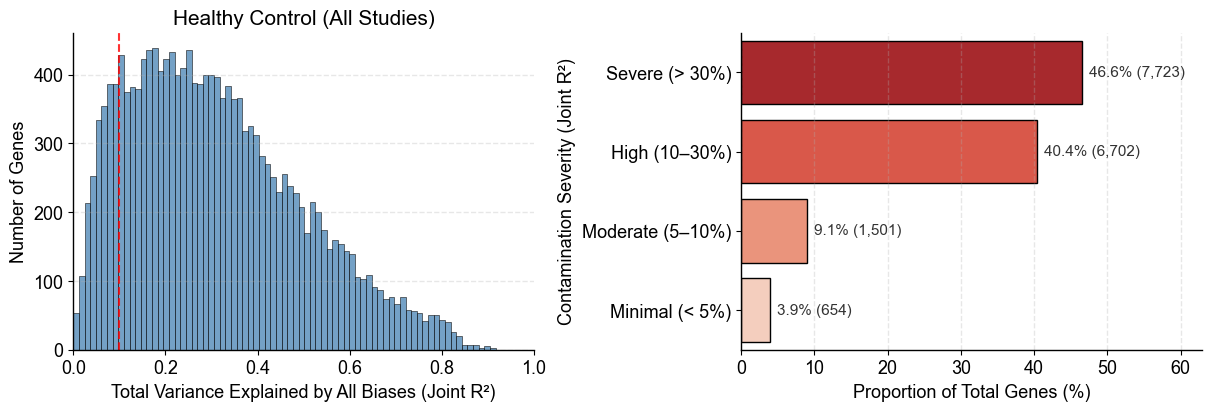

In [6]:
import os
from analysis_plot import plot_gene_wise_bias_summary

os.makedirs("./Analysis_Results/hc", exist_ok=True)
plot_gene_wise_bias_summary(
    df_hc_detail,
    group_name="Healthy Control (All Studies)",
    save_path="./Analysis_Results/hc/gene_wise_bias_rda_summary.png",
)


 > Chalasani et al.  (n=993)

--- [Chalasani et al.] Vectorized Gene-wise Partial RDA ---
[Chalasani et al.] Valid samples : 993
[Chalasani et al.] Genes analyzed (≥10% expressed) : 15,641
[Chalasani et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.8837   0.1266                 6910     > 10%
                Unique: log(Total Reads)  0.0738   0.0044                   19      > 5%
               Unique: Spliced Reads (%)  0.6217   0.0180                 1347      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1115   0.0059                   83      > 5%
                   Unique: rRNA Fraction  0.0518   0.0018                    1      > 5%
       Unique: RNA Degradation (3' Bias)  0.0954   0.0037                   35      > 5%
                  Unique: Platelet Score  0.3614   0.0136     

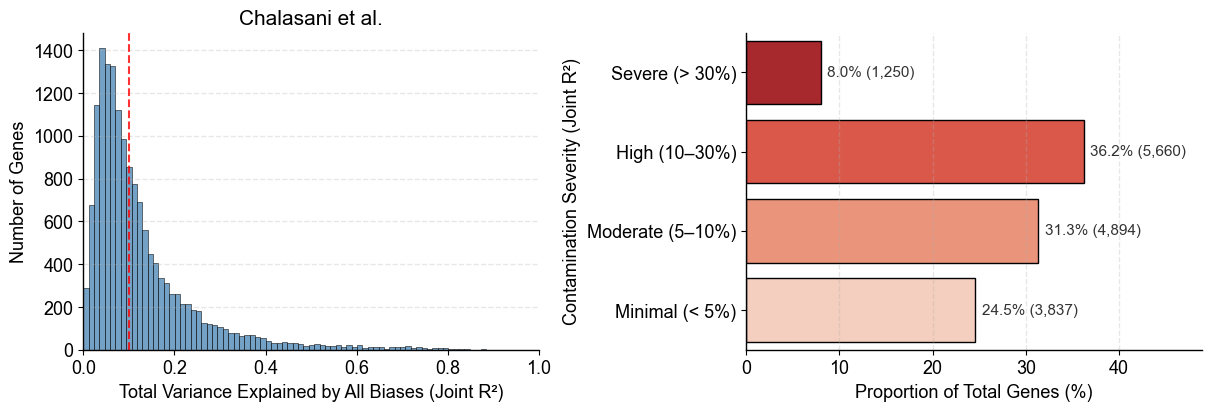


 > Ward Z et al.  (n=340)

--- [Ward Z et al.] Vectorized Gene-wise Partial RDA ---
[Ward Z et al.] Valid samples : 340
[Ward Z et al.] Genes analyzed (≥10% expressed) : 16,290
[Ward Z et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9424   0.3094                14917     > 10%
                Unique: log(Total Reads)  0.1610   0.0112                  683      > 5%
               Unique: Spliced Reads (%)  0.1450   0.0081                  269      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1761   0.0101                  595      > 5%
                   Unique: rRNA Fraction  0.1543   0.0117                  677      > 5%
       Unique: RNA Degradation (3' Bias)  0.1292   0.0075                  276      > 5%
                  Unique: Platelet Score  0.2565   0.0155                 128

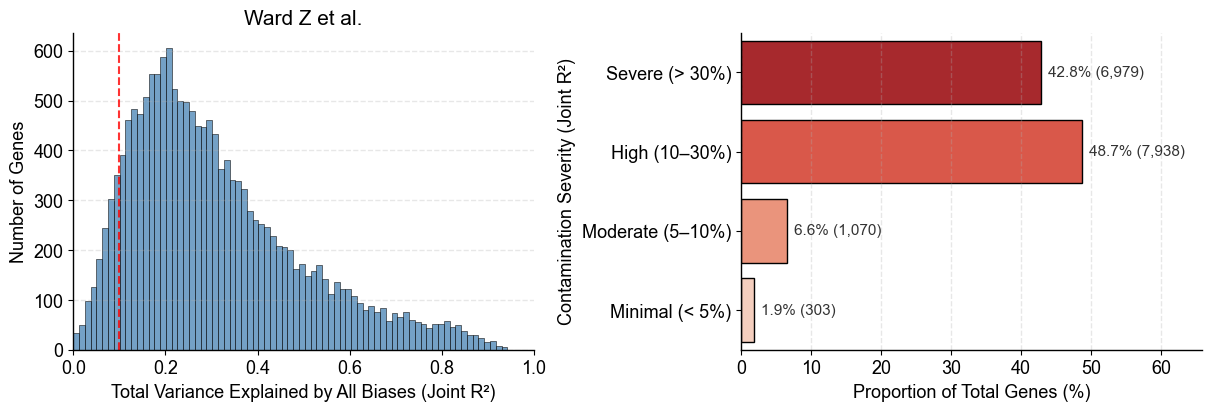


 > Toden et al.  (n=331)

--- [Toden et al.] Vectorized Gene-wise Partial RDA ---
[Toden et al.] Valid samples : 331
[Toden et al.] Genes analyzed (≥10% expressed) : 18,338
[Toden et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9281   0.2516                13524     > 10%
                Unique: log(Total Reads)  0.0991   0.0044                   40      > 5%
               Unique: Spliced Reads (%)  0.1307   0.0119                  854      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1800   0.0075                  328      > 5%
                   Unique: rRNA Fraction  0.0450   0.0022                    0      > 5%
       Unique: RNA Degradation (3' Bias)  0.2330   0.0145                 1093      > 5%
                  Unique: Platelet Score  0.3560   0.0143                 1171    

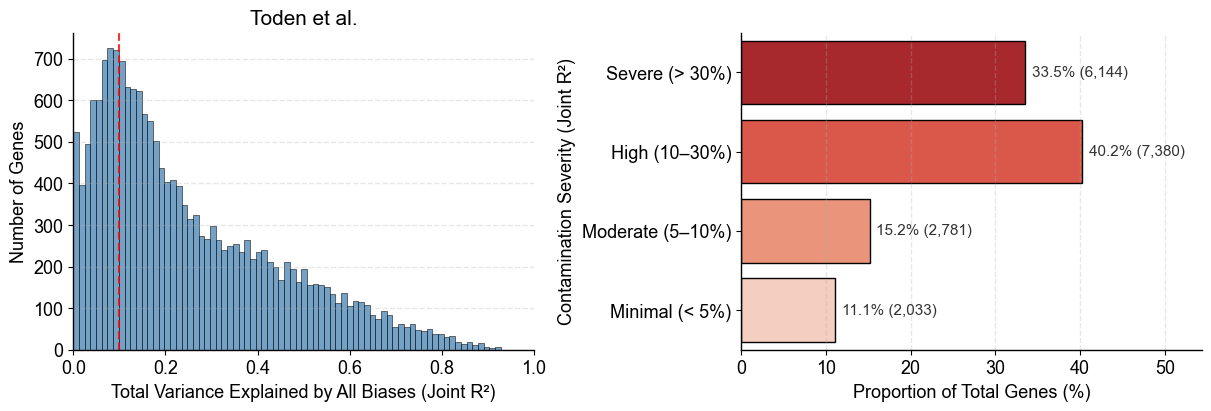


 > Moore et al.  (n=277)

--- [Moore et al.] Vectorized Gene-wise Partial RDA ---
[Moore et al.] Valid samples : 277
[Moore et al.] Genes analyzed (≥10% expressed) : 15,024
[Moore et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.8967   0.2054                11847     > 10%
                Unique: log(Total Reads)  0.0819   0.0032                   10      > 5%
               Unique: Spliced Reads (%)  0.1114   0.0032                   48      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1921   0.0057                  253      > 5%
                   Unique: rRNA Fraction  0.1128   0.0035                   30      > 5%
       Unique: RNA Degradation (3' Bias)  0.1538   0.0042                   78      > 5%
                  Unique: Platelet Score  0.3987   0.0123                  928    

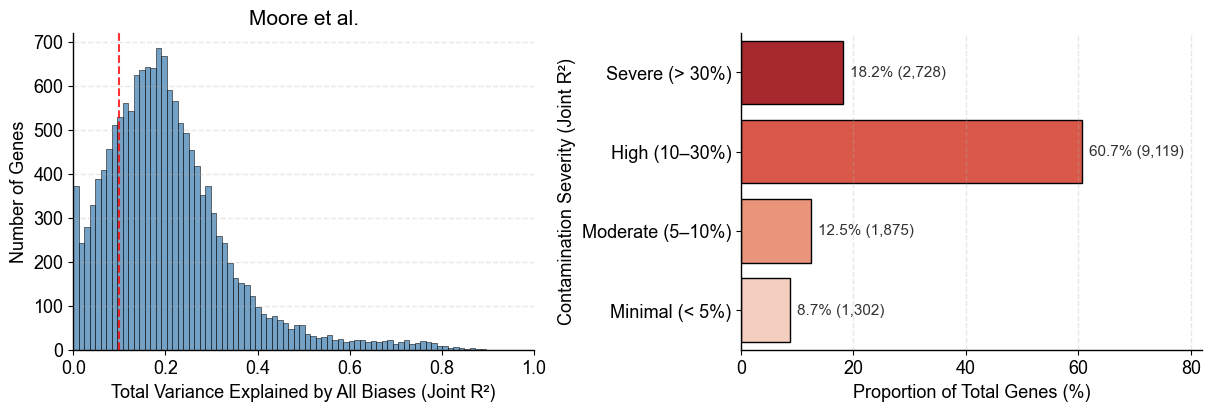


 > Moufarrej et al.  (n=256)

--- [Moufarrej et al.] Vectorized Gene-wise Partial RDA ---
[Moufarrej et al.] Valid samples : 256
[Moufarrej et al.] Genes analyzed (≥10% expressed) : 15,816
[Moufarrej et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9109   0.2492                12160     > 10%
                Unique: log(Total Reads)  0.1238   0.0039                   38      > 5%
               Unique: Spliced Reads (%)  0.0780   0.0030                   14      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1126   0.0051                  167      > 5%
                   Unique: rRNA Fraction  0.1104   0.0031                   15      > 5%
       Unique: RNA Degradation (3' Bias)  0.1274   0.0046                  111      > 5%
                  Unique: Platelet Score  0.1697   0.0062     

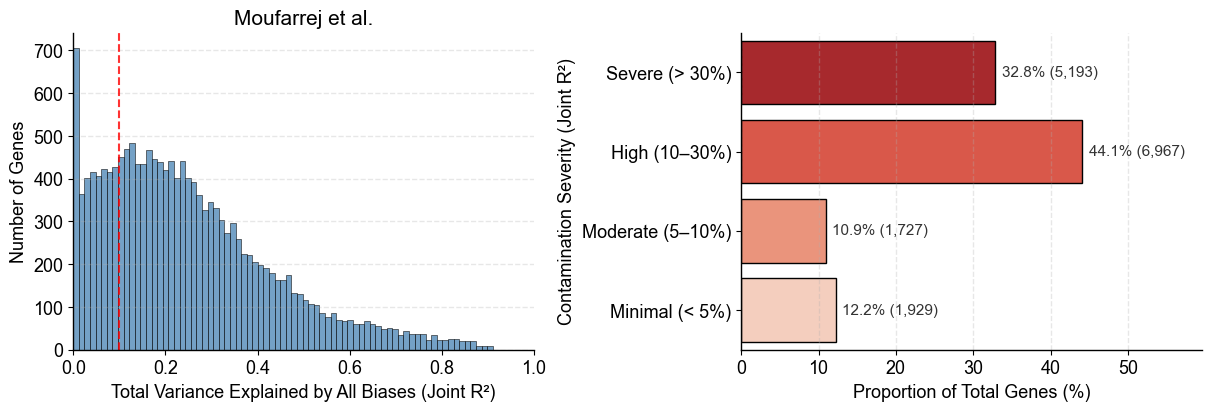


 > Chang et al.  (n=205)

--- [Chang et al.] Vectorized Gene-wise Partial RDA ---
[Chang et al.] Valid samples : 205
[Chang et al.] Genes analyzed (≥10% expressed) : 17,121
[Chang et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9612   0.2475                12398     > 10%
                Unique: log(Total Reads)  0.1473   0.0071                  362      > 5%
               Unique: Spliced Reads (%)  0.1157   0.0044                   90      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1353   0.0043                  107      > 5%
                   Unique: rRNA Fraction  0.0890   0.0049                   88      > 5%
       Unique: RNA Degradation (3' Bias)  0.1367   0.0047                  151      > 5%
                  Unique: Platelet Score  0.2088   0.0090                  765    

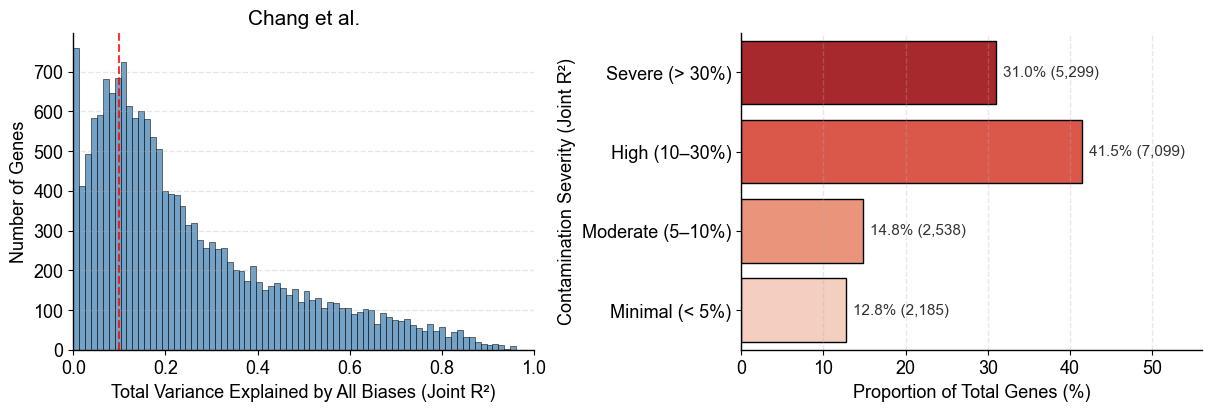


 > Chen et al.  (n=176)

--- [Chen et al.] Vectorized Gene-wise Partial RDA ---
[Chen et al.] Valid samples : 176
[Chen et al.] Genes analyzed (≥10% expressed) : 17,732
[Chen et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9199   0.4763                17303     > 10%
                Unique: log(Total Reads)  0.2643   0.0085                  296      > 5%
               Unique: Spliced Reads (%)  0.2726   0.0086                  480      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.3133   0.0174                 1839      > 5%
                   Unique: rRNA Fraction  0.2583   0.0108                  782      > 5%
       Unique: RNA Degradation (3' Bias)  0.2855   0.0078                  331      > 5%
                  Unique: Platelet Score  0.4388   0.0225                 2347      > 5

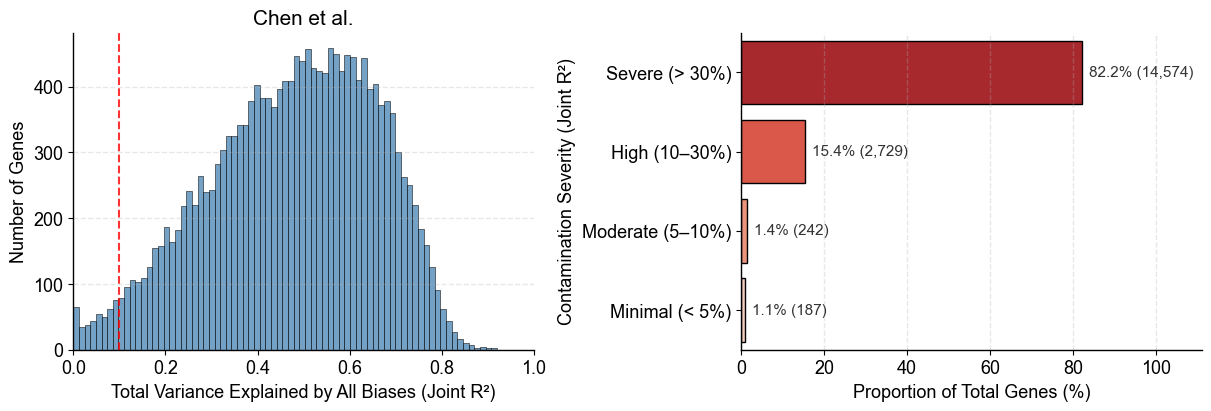


 > Gardella et al.  (n=163)

--- [Gardella et al.] Vectorized Gene-wise Partial RDA ---
[Gardella et al.] Valid samples : 163
[Gardella et al.] Genes analyzed (≥10% expressed) : 16,131
[Gardella et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9458   0.4079                13306     > 10%
                Unique: log(Total Reads)  0.1205   0.0055                  174      > 5%
               Unique: Spliced Reads (%)  0.2544   0.0115                  962      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.2257   0.0133                 1049      > 5%
                   Unique: rRNA Fraction  0.1683   0.0097                  584      > 5%
       Unique: RNA Degradation (3' Bias)  0.4478   0.0181                 1531      > 5%
                  Unique: Platelet Score  0.3771   0.0157          

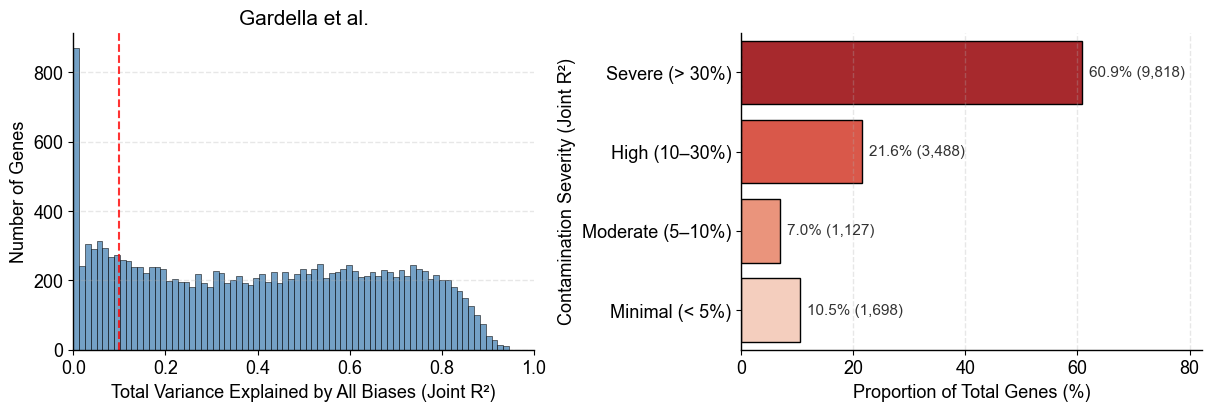


 > Roskams-Hieter B et al.  (n=88)

--- [Roskams-Hieter B et al.] Vectorized Gene-wise Partial RDA ---
[Roskams-Hieter B et al.] Valid samples : 88
[Roskams-Hieter B et al.] Genes analyzed (≥10% expressed) : 17,504
[Roskams-Hieter B et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9312   0.3364                14085     > 10%
                Unique: log(Total Reads)  0.2704   0.0086                  721      > 5%
               Unique: Spliced Reads (%)  0.2176   0.0092                  767      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.4085   0.0136                 1421      > 5%
                   Unique: rRNA Fraction  0.2787   0.0104                  939      > 5%
       Unique: RNA Degradation (3' Bias)  0.3798   0.0113                 1085      > 5%
                  Unique: Pla

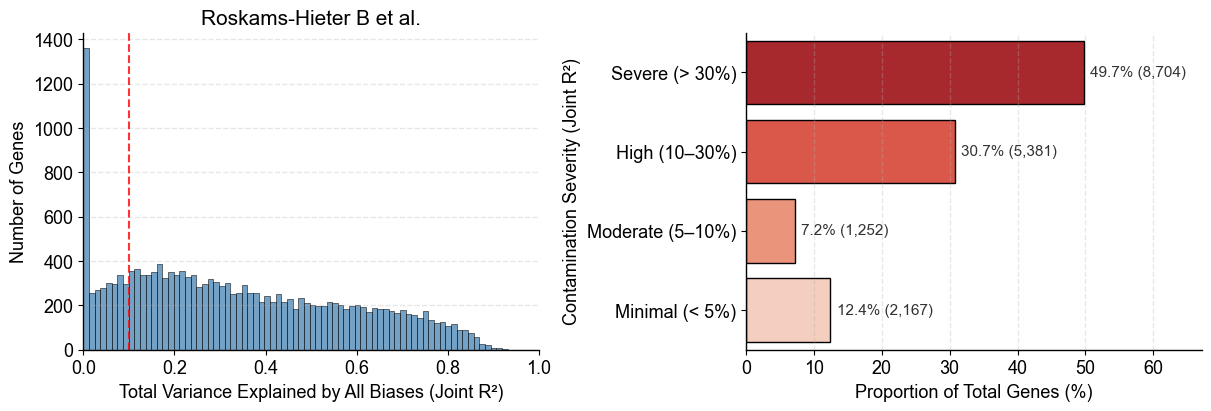

: 

In [ ]:
from analysis_plot import plot_gene_wise_bias_summary

study_bias_metrics = combined_metrics + ["Phenotype_Processed"]
MIN_SAMPLES = 30
all_study_summaries = {}
for study in pipeline_rda.valid_studies:
    adata_study = adata_rda[adata_rda.obs["Author"] == study]
    n_samples = len(adata_study)
    if n_samples < MIN_SAMPLES:
        print(f"[Skip] {study}: {n_samples} (< {MIN_SAMPLES})")
        continue

    print(f"\n{'='*60}\n > {study}  (n={n_samples})\n{'='*60}")
    df_detail, df_summary = compute_gene_wise_bias_rda(
        adata_study,
        bias_metrics=study_bias_metrics,
        target_labels=None,
        group_name=study,
        layer="CPM_log1p",
        min_expressed_frac=0.1,
    )
    
    df_summary["Pct_Highly_Biased"] = (df_summary["Genes_Highly_Biased"] / len(df_detail)) * 100
    all_study_summaries[study] = {"detail": df_detail, "summary": df_summary}
    slug = study.replace(" ", "_").replace(".", "_")
    save_dir = f"./Analysis_Results/gene_wise_bias/"
    os.makedirs(save_dir, exist_ok=True)
    plot_gene_wise_bias_summary(
        df_detail,
        group_name=study,
        save_path=f"{save_dir}/{slug}_gene_wise_bias_rda_summary.png",
    )